In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('../data/raw/Titanic-Dataset.csv')
df.head(8)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [323]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [324]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [325]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### DATA CLEANING

In [326]:
df['Age'] = df['Age'].fillna(df['Age'].mean()).astype(int)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}).astype(int)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

df[['Sex', 'Age', 'Embarked']].head()

,Sex,Age,Embarked
0,0,22,0
1,1,38,1
2,1,26,0
3,1,35,0
4,0,35,0


In [327]:
df[['Sex', 'Age', 'Embarked']].isnull().sum()

Sex         0
Age         0
Embarked    0
dtype: int64

In [328]:
print(df.columns.to_list())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [329]:
# не нужные столбцы
df_clean = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22,1,0,7.2500,0
1,1,1,1,38,1,0,71.2833,1
2,1,3,1,26,0,0,7.9250,0
3,1,1,1,35,1,0,53.1000,0
4,0,3,0,35,0,0,8.0500,0


In [330]:
df_clean.to_csv('../data/processed/titanic_cleaned.csv', index=False)

### Visualization

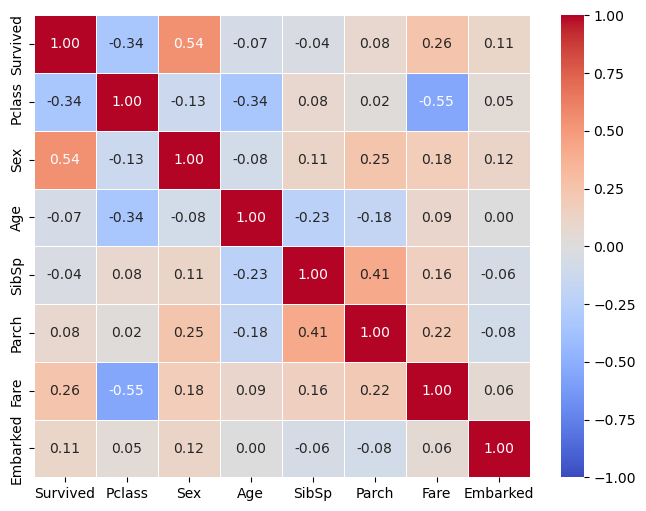

In [332]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.savefig('../reports/figures/corr.png')
plt.show()


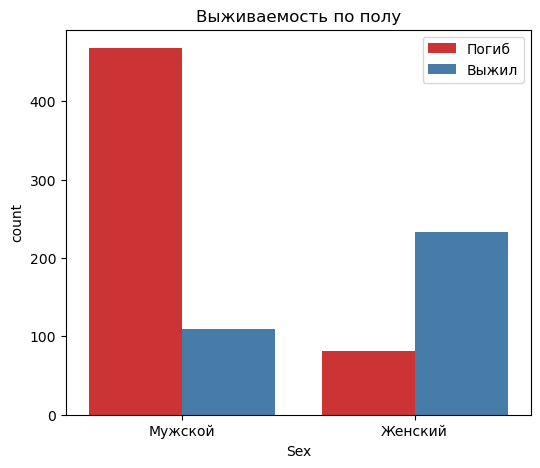

In [333]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Sex', hue='Survived', data=df_clean, palette='Set1')
plt.title('Выживаемость по полу')
plt.legend(['Погиб', 'Выжил'])
plt.xticks([0, 1], ['Мужской', 'Женский'])
plt.savefig('../reports/figures/sex.png')
plt.show()

C:\Users\amina\AppData\Local\Temp\ipykernel_29076\2840178828.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_clean, palette='Blues')


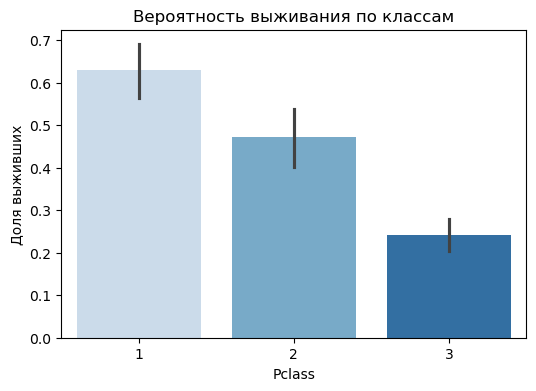

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df_clean, palette='Blues')
plt.title('Вероятность выживания по классам')
plt.ylabel('Доля выживших')
plt.savefig('../reports/figures/surviv_pclass.png')
plt.show()

Text(0.5, 36.72222222222221, 'Возраст')

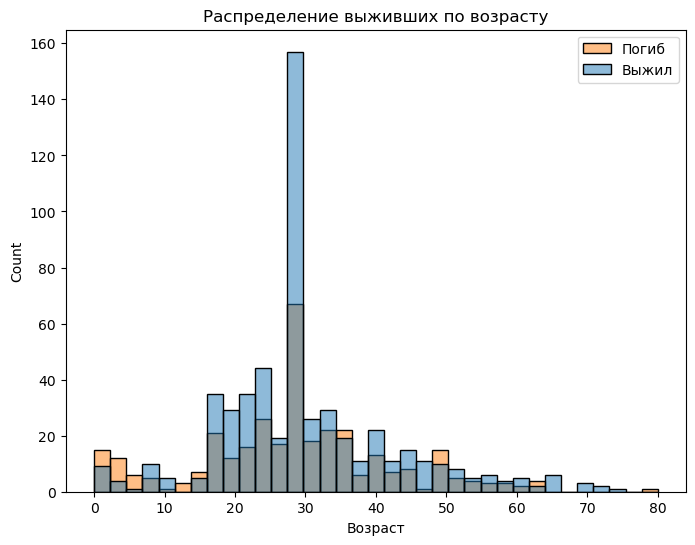

In [335]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Age', hue='Survived', data=df_clean, bins=35)
plt.legend(['Погиб', 'Выжил'])
plt.title('Распределение выживших по возрасту')
plt.savefig('../reports/figures/violin_age_pclass.png')
plt.xlabel('Возраст')

C:\Users\amina\AppData\Local\Temp\ipykernel_29076\2010110574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Survived', data=df_clean, palette='Blues')


<function matplotlib.pyplot.show(close=None, block=None)>

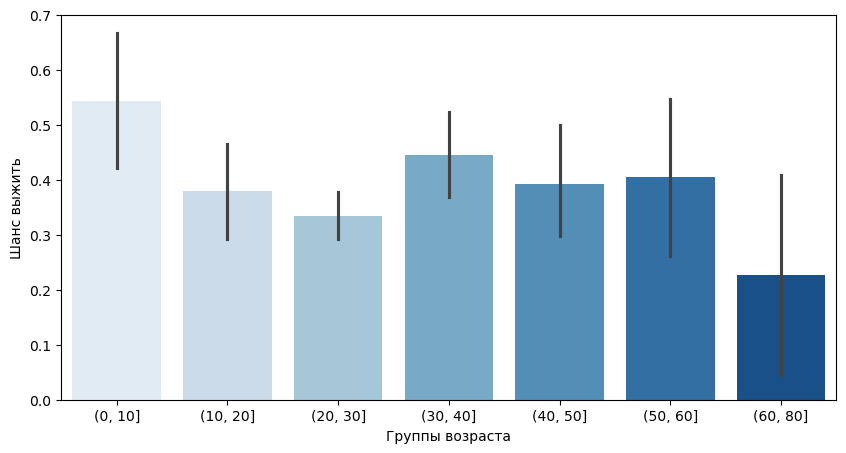

In [ ]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80])
plt.figure(figsize=(10, 5))
sns.barplot(x='Age_Group', y='Survived', data=df_clean, palette='Blues', )
plt.ylabel('Шанс выжить')
plt.xlabel('Группы возраста')
plt.savefig('../reports/figures/age.png')
plt.show

In [ ]:
# Строим график доли выживших по возрастным группам
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Age_Group',
    y='Survived',
    hue='Age_Group',   # назначаем x также как hue
    data=df_clean,
    palette='Blues',
    legend=False       # скрываем лишнюю легенду
)

plt.ylabel('Шанс выжить')
plt.xlabel('Группы возраста')
plt.title('Выживаемость по возрастным группам')

# Сохраняем график
plt.savefig('../reports/figures/age.png')

# Показываем график: нужны круглые скобки
plt.show()